# Pipeline Features Analysis

This notebook analyzes the enriched dataframe produced by `SiRNADataPipeline.enrich_dataset_with_encodings()` before `prepare_for_classical_ml()` flattens the feature blocks.

In [16]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.pipeline import SiRNADataPipeline
from utils.merge_historic_data import load_merged_dataset
from utils.sequence_encoding import SequenceEncoder
from utils.chemistry_encoding import ChemistryEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Configuration

In [17]:
use_merged_dataset = True
historic_path = os.environ.get("CMSIRNA_RAW_HISTORIC_DATA_PATH")
add_mrna = True
target_len = 25

# Example merged mode:
# use_merged_dataset = True
# historic_path = project_root / "data" / "Historic_Takayuki_hueskan_ichihara.csv"

## Load Dataset

In [18]:
cmsirna_path = os.environ.get("CMSIRNA_RAW_DATA_PATH")
assert cmsirna_path, "CMSIRNA_RAW_DATA_PATH is not set"

if use_merged_dataset:
    assert historic_path is not None, "Set historic_path before running merged mode"
    raw_df = load_merged_dataset(str(cmsirna_path), str(historic_path))
    data_source_label = "CMsiRNA + historic"
else:
    raw_df = pd.read_csv(cmsirna_path, sep="\t", low_memory=False)
    data_source_label = "CMsiRNA only"

if "Target_Gene" in raw_df.columns and "gene_target_symbol_name" not in raw_df.columns:
    raw_df = raw_df.rename(columns={"Target_Gene": "gene_target_symbol_name"})

print("Data source:", data_source_label)
print("Raw shape:", raw_df.shape)
print("Unique genes:", raw_df["gene_target_symbol_name"].nunique())

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Data source: CMsiRNA + historic
Raw shape: (46668, 27)
Unique genes: 54


## Run Pipeline To The Enriched Dataframe

In [19]:
sirna_pipeline = SiRNADataPipeline(target_len=target_len, fetch_missing_mrna=False)
enriched_df = sirna_pipeline.enrich_dataset_with_encodings(
    raw_df,
    strict_cleaning=True,
    add_mrna=add_mrna,
)

print("Enriched shape:", enriched_df.shape)
enriched_df.head()

Running qc and data cleaning
dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 13 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA mapping for 54 genes...
[1/54] Processing CTNNB1...
  Found in local cache (3074

,ID,patent_ID,Authorization_status,Accession_number,gene_target_symbol_name,Gene_ID,The_name_of_double_helix,Antisense_seqence,length_anti_sense_strand,Modifications_AntiSense_strand,Modification_Types_Antisense_strand,Sense_seqence,length_sense_strand,Modification_Types_Sense_strand,Inhibition,SD,Cell_Type,Concentration,Time_of_administration,Title,mRNA,Concentration_nM,Time_of_administration_h,mRNA_five_prime,mRNA_three_prime,edit_distance,target_site_pct,Sense_Sequence_One_Hot,Antisense_Sequence_One_Hot,Sense_Acid_One_Hot,Sense_Sugar_One_Hot,Sense_Linker_One_Hot,Antisense_Acid_One_Hot,Antisense_Sugar_One_Hot,Antisense_Linker_One_Hot,Cell_Type_One_Hot,Concentration_log10_nM,Concentration_norm,Time_norm
0,001-01-01-00001-100n-48h-88.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D1,UUAGAAAGCUGAUGGACCAUAACUG,25.0,UUAGAAAGCUGAUGGACCAUAACUG,1*U || 2*U || 3*A || 4*G || 5*A || 6*A || 7*A ...,CAGUUAUGGUCCAUCAGCUUUCUAA,25.0,1*2'-O-Methylcytidine || 2*2'-O-Methyladenosin...,88.0,NaN,Hela,100.0,48.0,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,AAGCCUCUCGGUCUGUGGCAGCAGCGUUGGCCCGGCCCCGGGAGCG...,100.0,48.0,AAGCCUCUCGGUCUGUGGCAGCAGCGUUGGCCCGGCCCCGGGAGCG...,CACACUAACCAAGCUGAGUUUCCUAUGGGAACAAUUGAAGUAAACU...,0.0,0.236825,"[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [1.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 1....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",2.0,0.950412,0.268293
1,001-01-01-00002-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D2,UACAAUAGCAGACACCAUCUGAGGA,25.0,UACAAUAGCAGACACCAUCUGAGGA,1*U || 2*A || 3*C || 4*A || 5*A || 6*U || 7*A ...,UCCUCAGAUGGUGUCUGCUAUUGUA,25.0,1*2'-O-Methyluridine || 2*2'-O-Methylcytidine ...,90.0,NaN,Hela,100.0,48.0,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,AAGCCUCUCGGUCUGUGGCAGCAGCGUUGGCCCGGCCCCGGGAGCG...,100.0,48.0,AAGCCUCUCGGUCUGUGGCAGCAGCGUUGGCCCGGCCCCGGGAGCG...,CACACUAACCAAGCUGAGUUUCCUAUGGGAACAAUUGAAGUAAACU...,0.0,0.255693,"[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",2.0,0.950412,0.268293
2,001-01-01-00003-100n-48h-90.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D3,UGAACAAGACGUUGACUUGGAUCUG,25.0,UGAACAAGACGUUGACUUGGAUCUG,1*U || 2*G || 3*A || 4*A || 5*C || 6*A || 7*A ...,CAGAUCCAAGUCAACGUCUUGUUCA,25.0,1*2'-O-Methylcytidine || 2*2'-O-Methyladenosin...,90.0,NaN,Hela,100.0,48.0,用于抑制CTNNB1靶基因mRNA表达的寡核酸分子及其成套组合物,AAGCCUCUCGGUCUGUGGCAGCAGCGUUGGCCCGGCCCCGGGAGCG...,100.0,48.0,AAGCCUCUCGGUCUGUGGCAGCAGCGUUGGCCCGGCCCCGGGAGCG...,CACACUAACCAAGCUGAGUUUCCUAUGGGAACAAUUGAAGUAAACU...,0.0,0.431034,"[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], [1.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...",2.0,0.950412,0.268293
3,001-01-01-00004-100n-48h-89.00,CN107365771B,Unknown Status,NM_001330729.2,CTNNB1,1499.0,D4,UUUAGUUGCAGCAUCUGAAAGAUUC,25.0,UUUAGUUGCAGCAUCUGAAAGAUUC,1*U || 2*U || 3*U || 4*A || 5*G || 6*U || 7*U ...,GAAUCUUUCAGAUGCUGCAACUAAA,25.0,1*2'-O-Methylguanosine || 2*2'-O-Methyladenosi

## Included Columns In The Enriched Dataframe

In [31]:
included_columns = [
    "gene_target_symbol_name",
    "Inhibition",
    "Cell_Type",
    "Concentration",
    "Concentration_nM",
    "Concentration_log10_nM",
    "Time_of_administration",
    "Time_of_administration_h",
    "Time_norm",
    "mRNA",
    "mRNA_five_prime",
    "mRNA_three_prime",
    "edit_distance",
    "target_site_pct",
    "Cell_Type_One_Hot",
    "Sense_Sequence_One_Hot",
    "Antisense_Sequence_One_Hot",
    "Sense_Acid_One_Hot",
    "Sense_Sugar_One_Hot",
    "Sense_Linker_One_Hot",
    "Antisense_Acid_One_Hot",
    "Antisense_Sugar_One_Hot",
    "Antisense_Linker_One_Hot",
]
included_columns = [col for col in included_columns if col in enriched_df.columns]
included_columns

['gene_target_symbol_name',
 'Inhibition',
 'Cell_Type',
 'Concentration',
 'Concentration_nM',
 'Concentration_log10_nM',
 'Time_of_administration',
 'Time_of_administration_h',
 'Time_norm',
 'mRNA',
 'mRNA_five_prime',
 'mRNA_three_prime',
 'edit_distance',
 'target_site_pct',
 'Cell_Type_One_Hot',
 'Sense_Sequence_One_Hot',
 'Antisense_Sequence_One_Hot',
 'Sense_Acid_One_Hot',
 'Sense_Sugar_One_Hot',
 'Sense_Linker_One_Hot',
 'Antisense_Acid_One_Hot',
 'Antisense_Sugar_One_Hot',
 'Antisense_Linker_One_Hot']

## Scalar Feature Summary

In [35]:
scalar_columns = [
    "Inhibition",
    "Concentration_nM",
    "Concentration_log10_nM",
    "Time_of_administration_h",
    "edit_distance",
    "target_site_pct",
]
scalar_columns = [col for col in scalar_columns if col in enriched_df.columns]

scalar_summary = enriched_df[scalar_columns].apply(pd.to_numeric, errors="coerce").agg(["min", "max", "mean", "std"]).T
scalar_summary = scalar_summary.rename(columns={"mean": "avg"})
scalar_summary

,min,max,avg,std
Inhibition,-99.500000,100.000000,42.656130,33.919400
Concentration_nM,0.000170,200.000000,16.955705,27.492470
Concentration_log10_nM,-3.769551,2.301030,0.403965,1.112431
Time_of_administration_h,4.000000,168.000000,33.297660,18.122616
edit_distance,0.000000,10.000000,0.966455,1.527977
target_site_pct,0.000000,0.996424,0.452130,0.272084


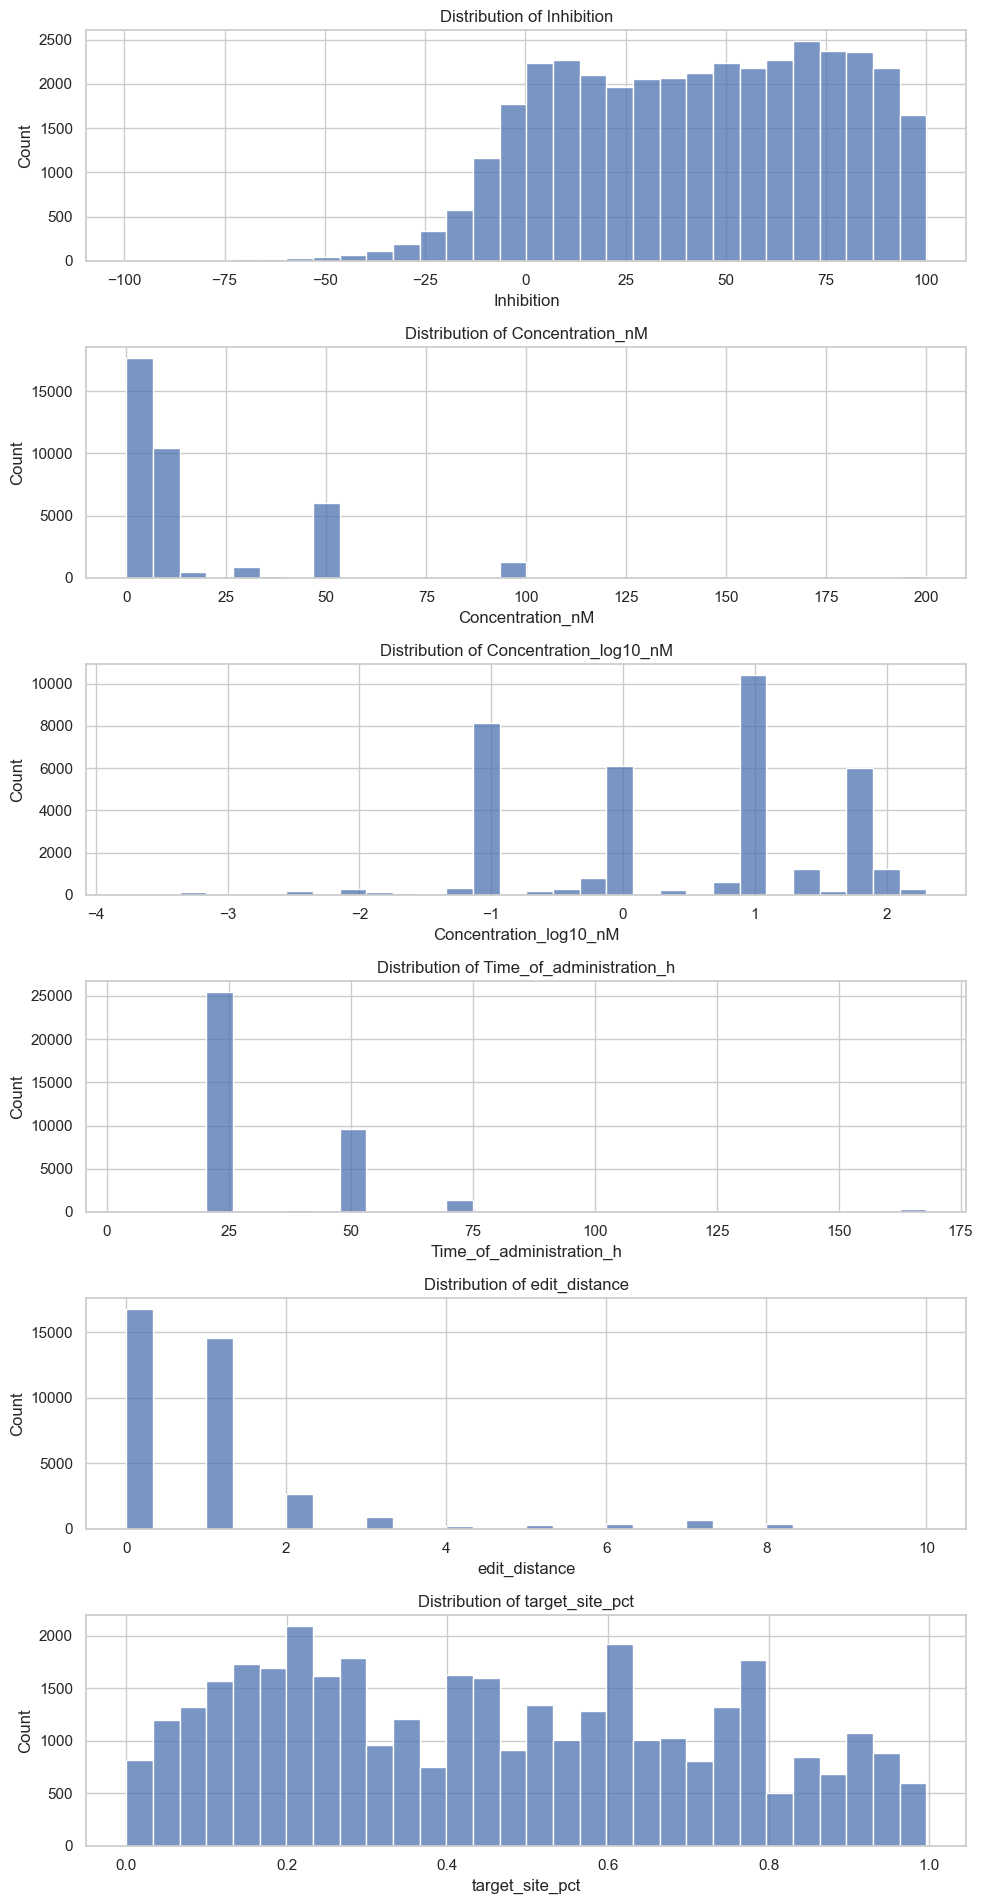

In [36]:
fig, axes = plt.subplots(len(scalar_columns), 1, figsize=(10, 3.2 * len(scalar_columns)))
if len(scalar_columns) == 1:
    axes = [axes]

for ax, column in zip(axes, scalar_columns):
    sns.histplot(pd.to_numeric(enriched_df[column], errors="coerce"), bins=30, ax=ax)
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()

## Categorical And Coverage Summary

In [37]:
coverage_summary = pd.Series({
    "rows": len(enriched_df),
    "unique_genes": enriched_df["gene_target_symbol_name"].nunique(),
    "unique_cell_types": enriched_df["Cell_Type"].nunique(),
    "rows_with_mRNA": int(enriched_df["mRNA"].notna().sum()) if "mRNA" in enriched_df.columns else 0,
    "rows_with_5p_utr": int(enriched_df["mRNA_five_prime"].notna().sum()) if "mRNA_five_prime" in enriched_df.columns else 0,
    "rows_with_3p_utr": int(enriched_df["mRNA_three_prime"].notna().sum()) if "mRNA_three_prime" in enriched_df.columns else 0,
    "rows_with_edit_distance": int(enriched_df["edit_distance"].notna().sum()) if "edit_distance" in enriched_df.columns else 0,
    "rows_with_target_site_pct": int(enriched_df["target_site_pct"].notna().sum()) if "target_site_pct" in enriched_df.columns else 0,
})
coverage_summary

rows                         36965
unique_genes                    54
unique_cell_types               21
rows_with_mRNA               36965
rows_with_5p_utr             33450
rows_with_3p_utr             33450
rows_with_edit_distance      36965
rows_with_target_site_pct    36965
dtype: int64

In [38]:
enriched_df["Cell_Type"].value_counts().head(20)

Cell_Type
Hep3B                                    12165
Primary Cynomolgus Monkey Hepatocytes     4445
COS7                                      3888
Primary human hepatocytes                 3015
H1299 Cells                               2394
Hela                                      2005
Be(2)C cell line                          1966
HepG2                                     1651
Huh7                                      1602
HEK293A                                   1048
HeLa Cells                                 783
Primary mouse hepatocytes                  501
Neuro2A cell line                          454
Human iPSC-derived cortical neurons        314
HEK293 Cells                               262
Non-human hepatocytes                      206
Hepa1-6                                    139
T24 Cells                                   76
Primary Macaque Hepatocytes                 22
RT-4                                        19
Name: count, dtype: int64

## One-Hot / Matrix Feature Summary

In [39]:
seq_encoder = SequenceEncoder(enriched_df.copy(), target_len=target_len)
seq_encoding_map = seq_encoder.build_encoding_map()
seq_symbols = list(seq_encoding_map.keys())

chem_encoder = ChemistryEncoder(enriched_df.copy(), target_len=target_len)
acid_symbols = list(chem_encoder.acid_map.keys())
sugar_symbols = list(chem_encoder.sugar_map.keys())
linker_symbols = list(chem_encoder.linker_map.keys())

cell_type_symbols = sorted(enriched_df["Cell_Type"].dropna().unique())

In [40]:
def summarize_vector_column(df, column_name, feature_names):
    matrix = np.stack(df[column_name].values)
    summary = pd.DataFrame({
        "feature": feature_names,
        "min": matrix.min(axis=0),
        "max": matrix.max(axis=0),
        "avg": matrix.mean(axis=0),
        "std": matrix.std(axis=0),
        "nonzero_fraction": (matrix != 0).mean(axis=0),
    })
    summary.insert(0, "column", column_name)
    return summary

def summarize_matrix_column(df, column_name, symbols):
    matrix3d = np.stack(df[column_name].values)
    flat = matrix3d.reshape(len(df), -1)
    feature_names = [
        f"pos{pos}_{symbol}"
        for pos in range(1, matrix3d.shape[1] + 1)
        for symbol in symbols
    ]
    summary = pd.DataFrame({
        "feature": feature_names,
        "min": flat.min(axis=0),
        "max": flat.max(axis=0),
        "avg": flat.mean(axis=0),
        "std": flat.std(axis=0),
        "nonzero_fraction": (flat != 0).mean(axis=0),
    })
    summary.insert(0, "column", column_name)
    return summary

In [41]:
feature_summaries = []

if "Cell_Type_One_Hot" in enriched_df.columns:
    feature_summaries.append(
        summarize_vector_column(enriched_df, "Cell_Type_One_Hot", [f"Cell_Type_{name}" for name in cell_type_symbols])
    )

matrix_specs = [
    ("Sense_Sequence_One_Hot", seq_symbols),
    ("Antisense_Sequence_One_Hot", seq_symbols),
    ("Sense_Acid_One_Hot", acid_symbols),
    ("Sense_Sugar_One_Hot", sugar_symbols),
    ("Sense_Linker_One_Hot", linker_symbols),
    ("Antisense_Acid_One_Hot", acid_symbols),
    ("Antisense_Sugar_One_Hot", sugar_symbols),
    ("Antisense_Linker_One_Hot", linker_symbols),
]

for column_name, symbols in matrix_specs:
    if column_name in enriched_df.columns:
        feature_summaries.append(summarize_matrix_column(enriched_df, column_name, symbols))

encoded_feature_summary = pd.concat(feature_summaries, ignore_index=True)
encoded_feature_summary.head(20)

,column,feature,min,max,avg,std,nonzero_fraction
0,Cell_Type_One_Hot,Cell_Type_Be(2)C cell line,0.0,1.0,0.053185,0.224403,0.053185
1,Cell_Type_One_Hot,Cell_Type_COS7,0.0,1.0,0.105181,0.306786,0.105181
2,Cell_Type_One_Hot,Cell_Type_H1299 Cells,0.0,1.0,0.064764,0.246109,0.064764
3,Cell_Type_One_Hot,Cell_Type_HEK293 Cells,0.0,1.0,0.007088,0.083890,0.007088
4,Cell_Type_One_Hot,Cell_Type_HEK293A,0.0,1.0,0.028351,0.165974,0.028351
5,Cell_Type_One_Hot,Cell_Type_HeLa Cells,0.0,1.0,0.021182,0.143991,0.021182
6,Cell_Type_One_Hot,Cell_Type_Hela,0.0,1.0,0.054240,0.226492,0.054240
7,Cell_Type_One_Hot,Cell_Type_Hep3B,0.0,1.0,0.329095,0.469885,0.329095
8,Cell_Type_One_Hot,Cell_Type_HepG2,0.0,1.0,0.044664,0.206565,0.044664
9,Cell_Type_One_Hot,Cell_Type_Hepa1-6,0.0,1.0,0.003760,0.061206,0.003760


In [42]:
encoded_feature_summary

,column,feature,min,max,avg,std,nonzero_fraction
0,Cell_Type_One_Hot,Cell_Type_Be(2)C cell line,0.0,1.0,0.053185,0.224403,0.053185
1,Cell_Type_One_Hot,Cell_Type_COS7,0.0,1.0,0.105181,0.306786,0.105181
2,Cell_Type_One_Hot,Cell_Type_H1299 Cells,0.0,1.0,0.064764,0.246109,0.064764
3,Cell_Type_One_Hot,Cell_Type_HEK293 Cells,0.0,1.0,0.007088,0.083890,0.007088
4,Cell_Type_One_Hot,Cell_Type_HEK293A,0.0,1.0,0.028351,0.165974,0.028351
...,...,...,...,...,...,...,...
1416,Antisense_Linker_One_Hot,pos25_PS,0.0,0.0,0.000000,0.000000,0.000000
1417,Antisense_Linker_One_Hot,pos25_VP,0.0,0.0,0.000000,0.000000,0.000000
1418,Antisense_Linker_One_Hot,pos25_Both_VP_PS,0.0,0.0,0.000000,0.000000,0.000000
1419,Antisense_Linker_One_Hot,pos25_Phosphonate,0.0,0.0,0.000000,0.000000,0.000000


## Heatmaps Of Mean Activation By Position

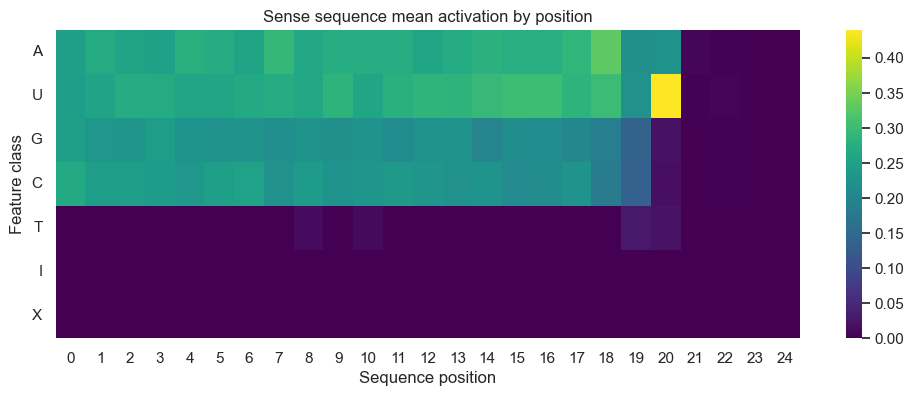

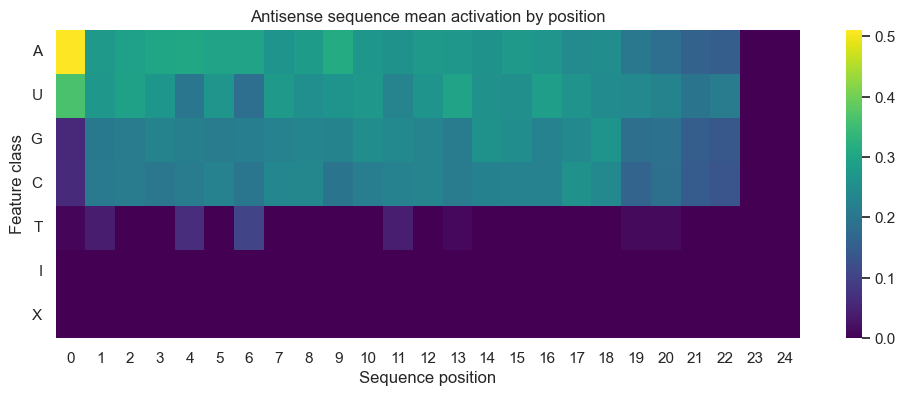

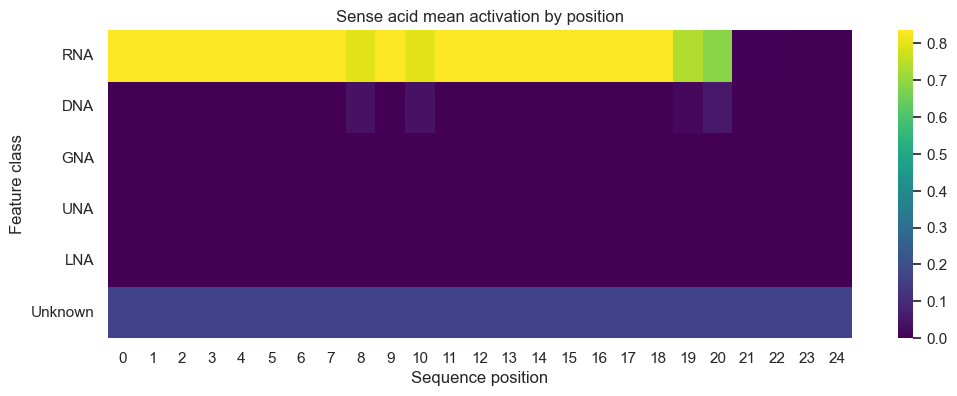

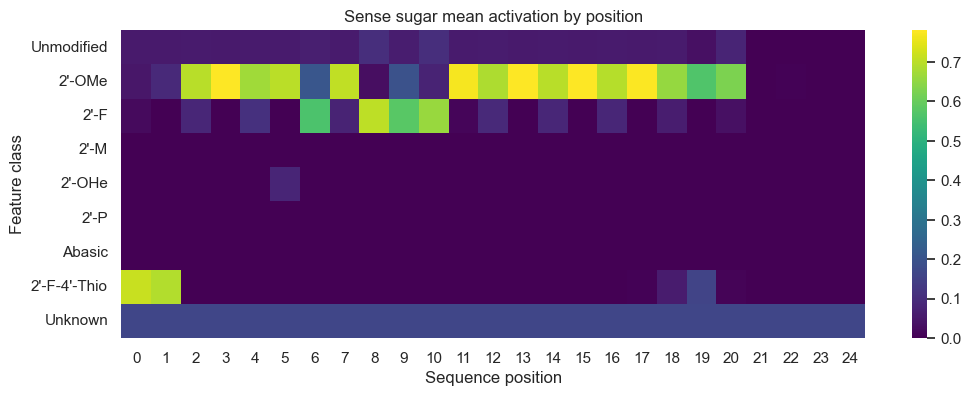

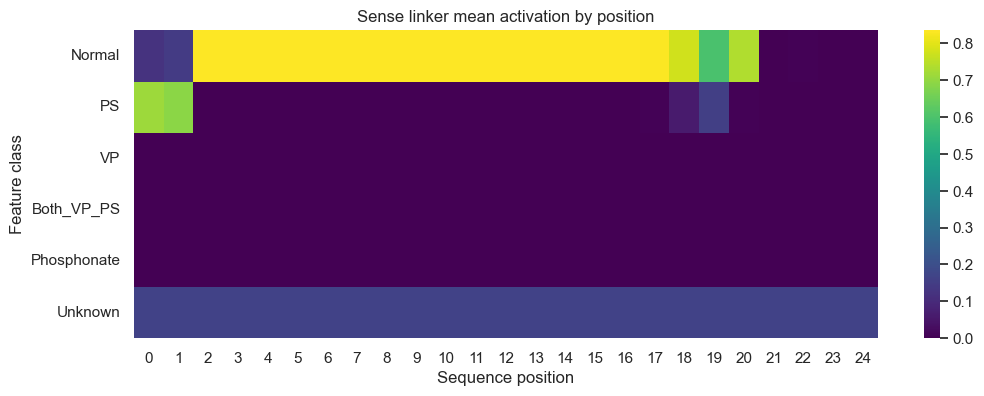

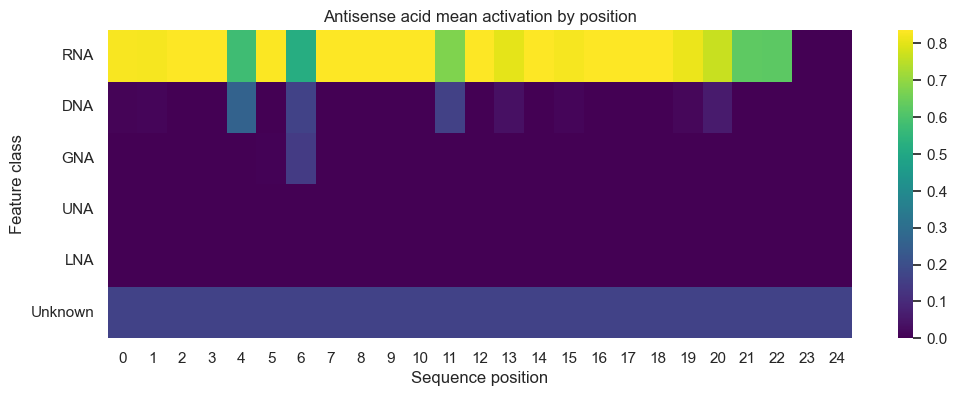

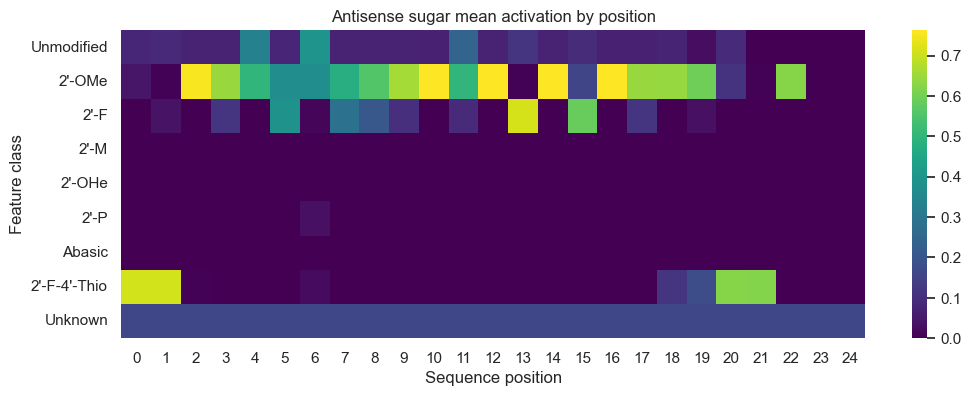

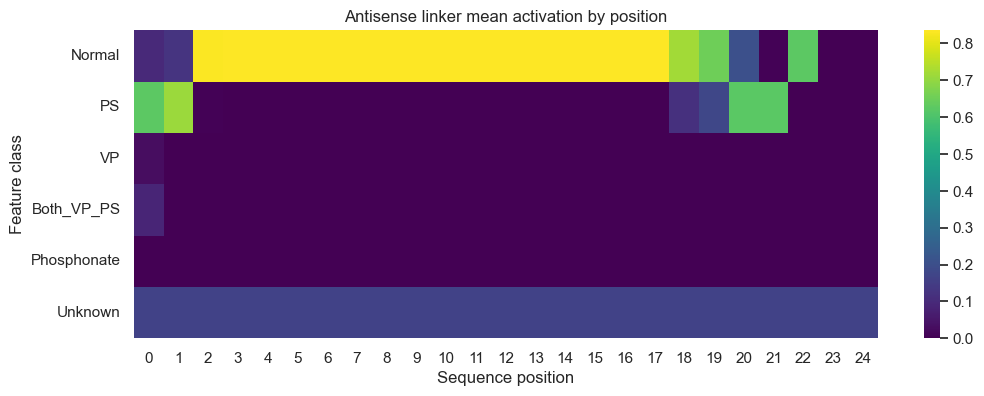

In [43]:
def plot_mean_activation_heatmap(df, column_name, labels, title):
    matrix3d = np.stack(df[column_name].values)
    mean_matrix = matrix3d.mean(axis=0)
    plt.figure(figsize=(12, 4))
    sns.heatmap(mean_matrix.T, cmap="viridis", cbar=True)
    plt.xlabel("Sequence position")
    plt.ylabel("Feature class")
    plt.yticks(np.arange(len(labels)) + 0.5, labels, rotation=0)
    plt.title(title)
    plt.show()

heatmap_specs = [
    ("Sense_Sequence_One_Hot", seq_symbols, "Sense sequence mean activation by position"),
    ("Antisense_Sequence_One_Hot", seq_symbols, "Antisense sequence mean activation by position"),
    ("Sense_Acid_One_Hot", acid_symbols, "Sense acid mean activation by position"),
    ("Sense_Sugar_One_Hot", sugar_symbols, "Sense sugar mean activation by position"),
    ("Sense_Linker_One_Hot", linker_symbols, "Sense linker mean activation by position"),
    ("Antisense_Acid_One_Hot", acid_symbols, "Antisense acid mean activation by position"),
    ("Antisense_Sugar_One_Hot", sugar_symbols, "Antisense sugar mean activation by position"),
    ("Antisense_Linker_One_Hot", linker_symbols, "Antisense linker mean activation by position"),
]

for column_name, labels, title in heatmap_specs:
    if column_name in enriched_df.columns:
        plot_mean_activation_heatmap(enriched_df, column_name, labels, title)

## Optional Export

In [44]:
processed_dir = os.environ.get("CMSIRNA_PROCESSED_DIR")
if processed_dir:
    output_dir = Path(processed_dir)
    scalar_summary_path = output_dir / "pipeline_scalar_feature_summary.csv"
    encoded_summary_path = output_dir / "pipeline_encoded_feature_summary.csv"
    scalar_summary.to_csv(scalar_summary_path)
    encoded_feature_summary.to_csv(encoded_summary_path, index=False)
    print("Saved scalar summary to:", scalar_summary_path)
    print("Saved encoded summary to:", encoded_summary_path)
else:
    print("CMSIRNA_PROCESSED_DIR is not set; skipping export.")

Saved scalar summary to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/pipeline_scalar_feature_summary.csv
Saved encoded summary to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed/pipeline_encoded_feature_summary.csv
